# Self Organizing Maps
___

In [17]:
#Library Import
import numpy as np
from numba import jit
from PIL import Image
import os
import matplotlib.pyplot as plt
import pickle
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

#### Code

In [9]:
class NumbaSOM:
    def __init__(self, x, y, input_len, learning_rate=0.5, sigma=None):
        """
        Initialize the SOM.
        :param x: Number of rows in the SOM grid.
        :param y: Number of columns in the SOM grid.
        :param input_len: Length of the input vector.
        :param learning_rate: Initial learning rate.
        :param sigma: Initial neighborhood radius.
        """
        self.x = x
        self.y = y
        self.input_len = input_len
        self.learning_rate = learning_rate
        self.sigma = sigma if sigma else max(x, y) / 2.0
        self.weights = np.random.random((x, y, input_len))
        self.iteration = 0
    
    @staticmethod
    @jit(nopython=True)
    def euclidean_distance(vec1, vec2):
        """Calculate the Euclidean distance."""
        return np.sqrt(np.sum((vec1 - vec2) ** 2))
    
    def find_bmu(self, input_vector):
        """Find the Best Matching Unit (BMU) for a given input."""
        bmu_idx = None
        min_dist = float('inf')
        for i in range(self.x):
            for j in range(self.y):
                dist = self.euclidean_distance(self.weights[i, j], input_vector)
                if dist < min_dist:
                    min_dist = dist
                    bmu_idx = (i, j)
        return bmu_idx

    def decay_learning_rate(self, initial_rate, iteration, max_iterations):
        """Decay the learning rate."""
        return initial_rate * np.exp(-iteration / max_iterations)

    def decay_sigma(self, initial_sigma, iteration, max_iterations):
        """Decay the neighborhood radius."""
        return initial_sigma * np.exp(-iteration / max_iterations)

    def neighborhood_function(self, bmu, neighbor, sigma):
        """Calculate the neighborhood function."""
        dist = self.euclidean_distance(np.array(bmu), np.array(neighbor))
        return np.exp(-dist ** 2 / (2 * (sigma ** 2)))

    def update_weights(self, input_vector, bmu, sigma, learning_rate):
        """Update the SOM weights."""
        for i in range(self.x):
            for j in range(self.y):
                influence = self.neighborhood_function(bmu, (i, j), sigma)
                self.weights[i, j] += influence * learning_rate * (input_vector - self.weights[i, j])

    def train(self, data, num_iterations):
        """Train the SOM."""
        for iteration in range(num_iterations):
            self.iteration = iteration
            input_vector = data[np.random.randint(0, len(data))]
            bmu = self.find_bmu(input_vector)

            # Decay learning rate and sigma
            lr = self.decay_learning_rate(self.learning_rate, iteration, num_iterations)
            sig = self.decay_sigma(self.sigma, iteration, num_iterations)

            # Update weights
            self.update_weights(input_vector, bmu, sig, lr)

    def save(self, filename, folder="Pickle"):
        """
        Save the trained SOM to a pickle file.
        :param filename: Name of the file to save.
        :param folder: Folder where the pickle file will be saved.
        """
        os.makedirs(folder, exist_ok=True)  # Create folder if it doesn't exist
        file_path = os.path.join(folder, filename)
        with open(file_path, "wb") as f:
            pickle.dump(self, f)
        print(f"SOM saved to {file_path}")

In [5]:
def preprocess_images(folder_path, size=(64, 64)):
    images = []
    for file in os.listdir(folder_path):
        img = Image.open(os.path.join(folder_path, file)).convert("RGB")
        img = img.resize(size)
        img_array = np.array(img).flatten() / 255.0  # Normalize pixel values
        images.append(img_array)
    return np.array(images)

In [8]:
def visualize_som(som, data, image_paths, size=(64, 64)):
    bmu_map = {}
    for idx, input_vector in enumerate(data):
        bmu = som.find_bmu(input_vector)
        if bmu not in bmu_map:
            bmu_map[bmu] = []
        bmu_map[bmu].append(image_paths[idx])
    
    fig, ax = plt.subplots(som.x, som.y, figsize=(15, 15))
    for i in range(som.x):
        for j in range(som.y):
            ax[i, j].axis('off')
            if (i, j) in bmu_map:
                img = Image.open(bmu_map[(i, j)][0]).resize(size)
                ax[i, j].imshow(img)
    plt.show()

In [47]:
def fill_display_som(som, data, image_paths, size=(64, 64)):
    # Create a dictionary to store the images associated with each BMU
    bmu_map = {}

    # Assign images to their respective BMUs
    for idx, input_vector in enumerate(data):
        bmu = som.find_bmu(input_vector)  # Get BMU for the input vector
        if bmu not in bmu_map:
            bmu_map[bmu] = []
        bmu_map[bmu].append(image_paths[idx])  # Store the image associated with the BMU

    # Create a figure to display the SOM grid
    fig, ax = plt.subplots(som.x, som.y, figsize=(15, 15))

    for i in range(som.x):
        for j in range(som.y):
            ax[i, j].axis('off')  # Turn off axis for each subplot
            if (i, j) in bmu_map:  # Check if there are images for this BMU
                # Select the closest image to the SOM weight vector in the grid
                # We find the image with the smallest Euclidean distance to the SOM vector of this cell
                bmu_images = bmu_map[(i, j)]
                distances = []
                for img_path in bmu_images:
                    img_data = np.array(Image.open(img_path).resize(size)).flatten()  # Flatten image data
                    som_weight = som.weights[i, j].flatten()  # Directly access the SOM vector of the grid cell
                    dist = np.linalg.norm(img_data - som_weight)  # Calculate Euclidean distance
                    distances.append(dist)
                
                # Select the image with the smallest distance to the SOM weight vector
                closest_img = bmu_images[np.argmin(distances)]
                img = Image.open(closest_img).resize(size)
                ax[i, j].imshow(img)
            else:
                # If no image is assigned, fill the grid with a blank image (white)
                blank_img = np.ones((size[0], size[1], 3)) * 255  # Create a white image
                ax[i, j].imshow(blank_img)  # Display the blank image

    plt.tight_layout()
    plt.show()

In [14]:
def load_som(filename, folder="Pickle"):
    """
    Load a trained SOM from a pickle file.
    :param filename: Name of the pickle file.
    :param folder: Folder where the pickle file is stored.
    :return: Loaded NumbaSOM object.
    """
    file_path = os.path.join(folder, filename)
    with open(file_path, "rb") as f:
        som = pickle.load(f)
    print(f"SOM loaded from {file_path}")
    return som

In [40]:
def visualize_som_pca(som, data, image_paths, size=(64, 64)):
    # Standardize data for PCA
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)  # Scale the data before PCA

    # Apply PCA to the entire training dataset (reduce to 3 components for RGB color mapping)
    pca = PCA(n_components=3)
    pca_data = pca.fit_transform(data_scaled)

    # Apply PCA to the SOM cells (reduce to 3 components)
    som_weights = som.weights  # Ensure this is correct for your SOM
    som_weights_flattened = som_weights.reshape(-1, som_weights.shape[-1])  # Flatten the SOM grid
    
    # Standardize the SOM weights for PCA
    som_weights_scaled = scaler.transform(som_weights_flattened)
    pca_som = PCA(n_components=3)
    pca_som_data = pca_som.fit_transform(som_weights_scaled)

    # Create a figure to display the SOM grid with PCA coloring
    fig, ax = plt.subplots(2, 1, figsize=(12, 12))

    # First plot: SOM grid colored based on PCA of training data
    for i in range(som.x):
        for j in range(som.y):
            # Find the BMU (Best Matching Unit) for each SOM grid cell
            bmu = som.find_bmu(data[np.random.randint(0, len(data))])
            # Convert the BMU coordinates into a flattened index
            index = bmu[0] * som.y + bmu[1]  # Flattened index for PCA data
            # Get the PCA color for the corresponding input vector
            pca_rgb = pca_data[index]
            pca_rgb = np.clip(pca_rgb / np.max(np.abs(pca_rgb)), 0, 1)  # Normalize RGB values
            ax[0].add_patch(plt.Rectangle((j, i), 1, 1, color=pca_rgb))

    ax[0].set_title("SOM grid colored by PCA of training data")
    ax[0].axis('off')

    # Second plot: SOM grid colored based on PCA of SOM weights
    for i in range(som.x):
        for j in range(som.y):
            # Get the PCA components for each SOM cell
            pca_rgb_som = pca_som_data[i * som.y + j]  # Flattened index for SOM cell PCA data
            pca_rgb_som = np.clip(pca_rgb_som / np.max(np.abs(pca_rgb_som)), 0, 1)  # Normalize RGB values
            ax[1].add_patch(plt.Rectangle((j, i), 1, 1, color=pca_rgb_som))

    ax[1].set_title("SOM grid colored by PCA of SOM cells")
    ax[1].axis('off')

    plt.tight_layout()
    plt.show()

In [36]:
def display_som_with_closest_images(som, data, image_paths, size=(64, 64)):
    # Create a dictionary to store BMUs (Best Matching Units) and their image indices
    bmu_map = {}

    # Get all SOM vectors
    som_vectors = som.weights.reshape(-1, som.weights.shape[-1])

    # Find BMUs for each image and store indices of images for each BMU
    for idx, input_vector in enumerate(data):
        bmu = som.find_bmu(input_vector)
        if bmu not in bmu_map:
            bmu_map[bmu] = []
        bmu_map[bmu].append(idx)

    fig, ax = plt.subplots(som.x, som.y, figsize=(15, 15))

    for i in range(som.x):
        for j in range(som.y):
            ax[i, j].axis('off')
            
            # Find the BMU for this particular grid cell
            closest_idx = None
            closest_dist = float('inf')
            
            for idx in range(len(data)):
                # Calculate the Euclidean distance between the current SOM cell's weights and the image vector
                dist = np.linalg.norm(som_vectors[i * som.y + j] - data[idx])
                if dist < closest_dist:
                    closest_dist = dist
                    closest_idx = idx

            # Load the image corresponding to the closest index and display it
            img = Image.open(image_paths[closest_idx]).resize(size)
            ax[i, j].imshow(img)

    plt.show()

In [38]:
def display_som_activation(som, data, size=(64, 64)):
    # Create a dictionary to store BMUs (Best Matching Units) and their activation values
    activation_map = np.zeros((som.x, som.y))

    # Calculate activation for each SOM cell
    for input_vector in data:
        bmu = som.find_bmu(input_vector)  # Find BMU for each image
        activation_map[bmu[0], bmu[1]] += 1  # Increase activation for the BMU cell

    # Normalize the activation map to range [0, 1]
    activation_map = activation_map / np.max(activation_map)

    # Create a figure and axis to display the activation map
    fig, ax = plt.subplots(som.x, som.y, figsize=(15, 15))

    for i in range(som.x):
        for j in range(som.y):
            ax[i, j].axis('off')

            # Color code the activation values (White to Green)
            color = plt.cm.summer(activation_map[i, j])  # Use the 'summer' colormap (green to yellow)
            ax[i, j].imshow(np.ones((size[0], size[1], 3)) * color[:3])  # Fill the cell with the activation color

    plt.show()

#### Execute

In [6]:
data = preprocess_images(r"Image_Group_Test")

In [12]:
# Small grid for 100 images
x, y = 10, 10

som = NumbaSOM(x=x, y=y, input_len=data.shape[1], learning_rate=0.5)
som.train(data, num_iterations=300)

In [13]:
som.save("testing_train.pkl", folder="Pickle")

SOM saved to Pickle\testing_train.pkl


In [ ]:
# Example of loading the SOM
loaded_som = load_som("testing_train.pkl", folder="Pickle")

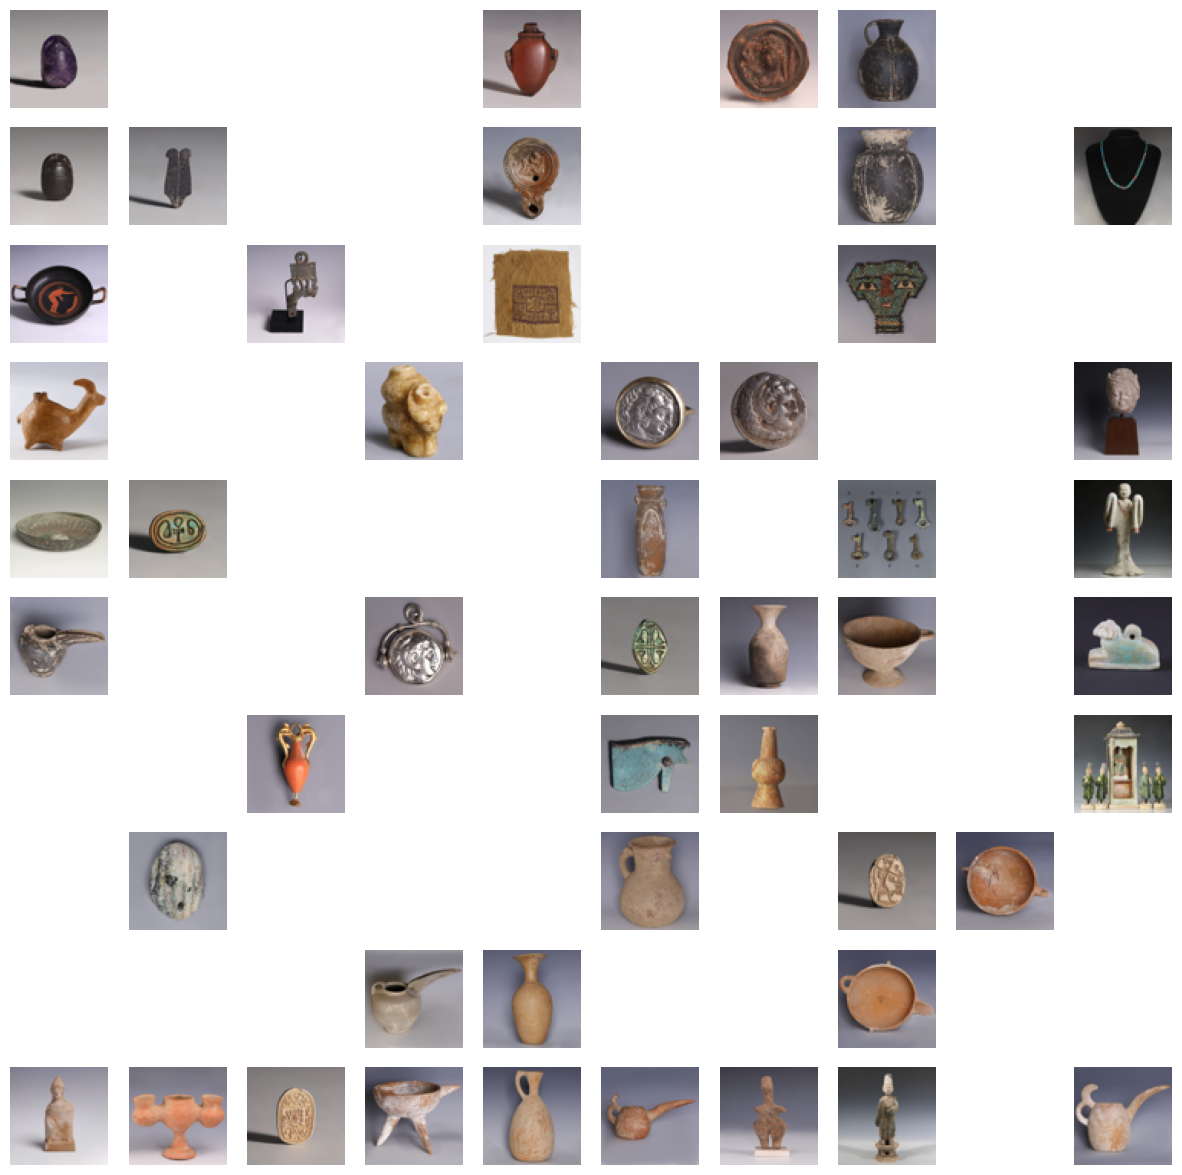

In [15]:
image_paths = [os.path.join("Image_Group_Test", file) for file in os.listdir("Image_Group_Test")]
visualize_som(som, data, image_paths)

#### Layering

1. PCA

SOM loaded from Pickle\testing_train.pkl


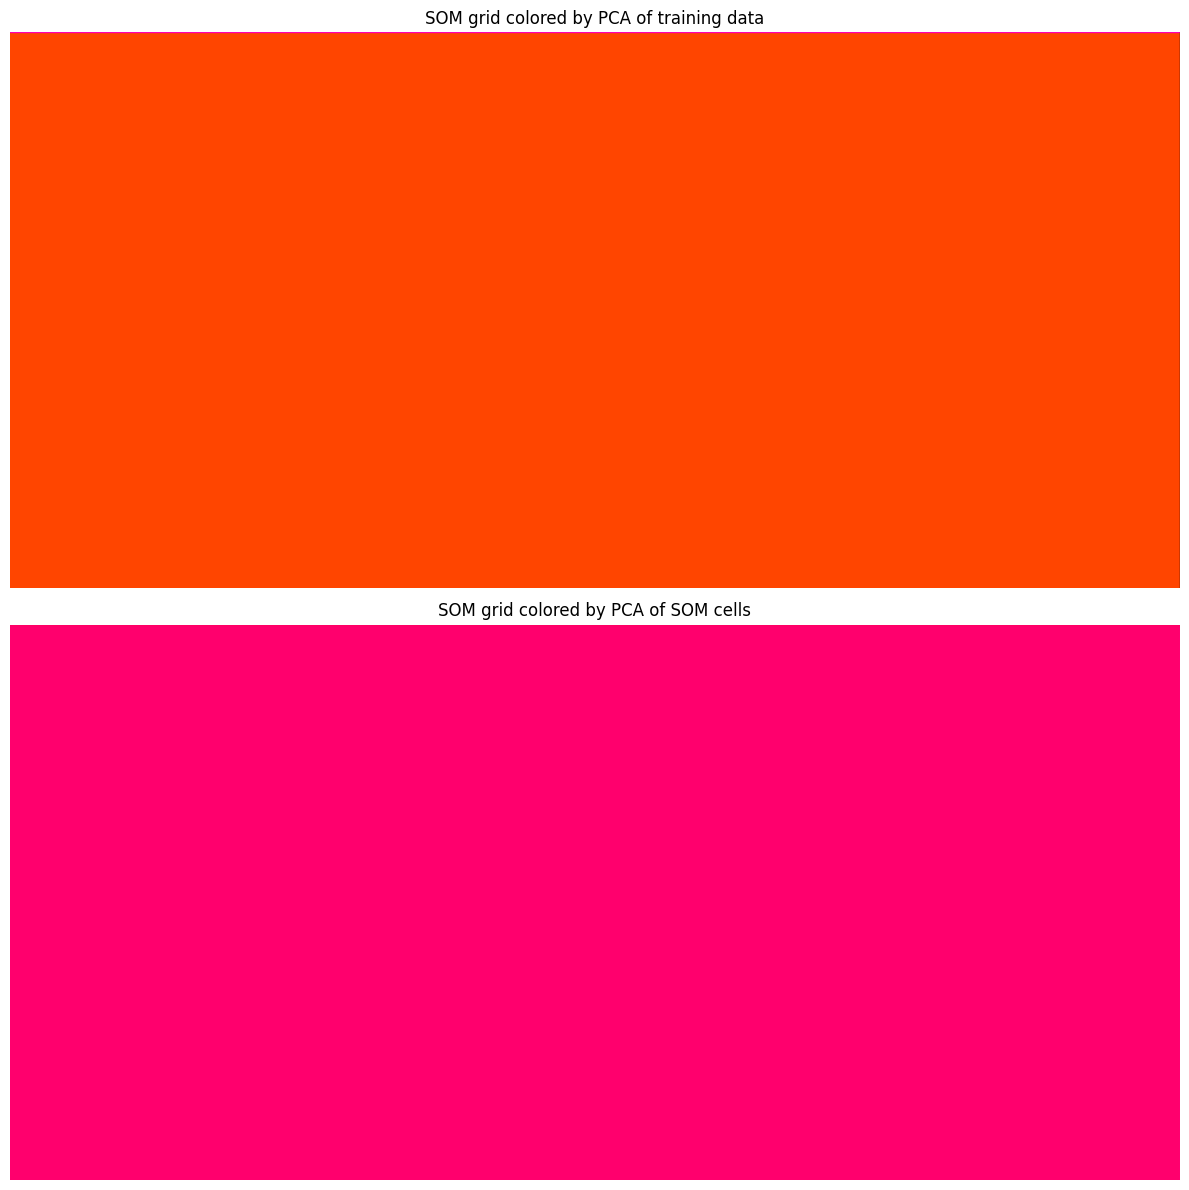

In [41]:
# Example of loading the SOM
loaded_som = load_som("testing_train.pkl", folder="Pickle")

# Visualizing SOM using PCA
image_paths = [os.path.join("Image_Group_Test", file) for file in os.listdir("Image_Group_Test")]
visualize_som_pca(loaded_som, data, image_paths)

2. Closest Image

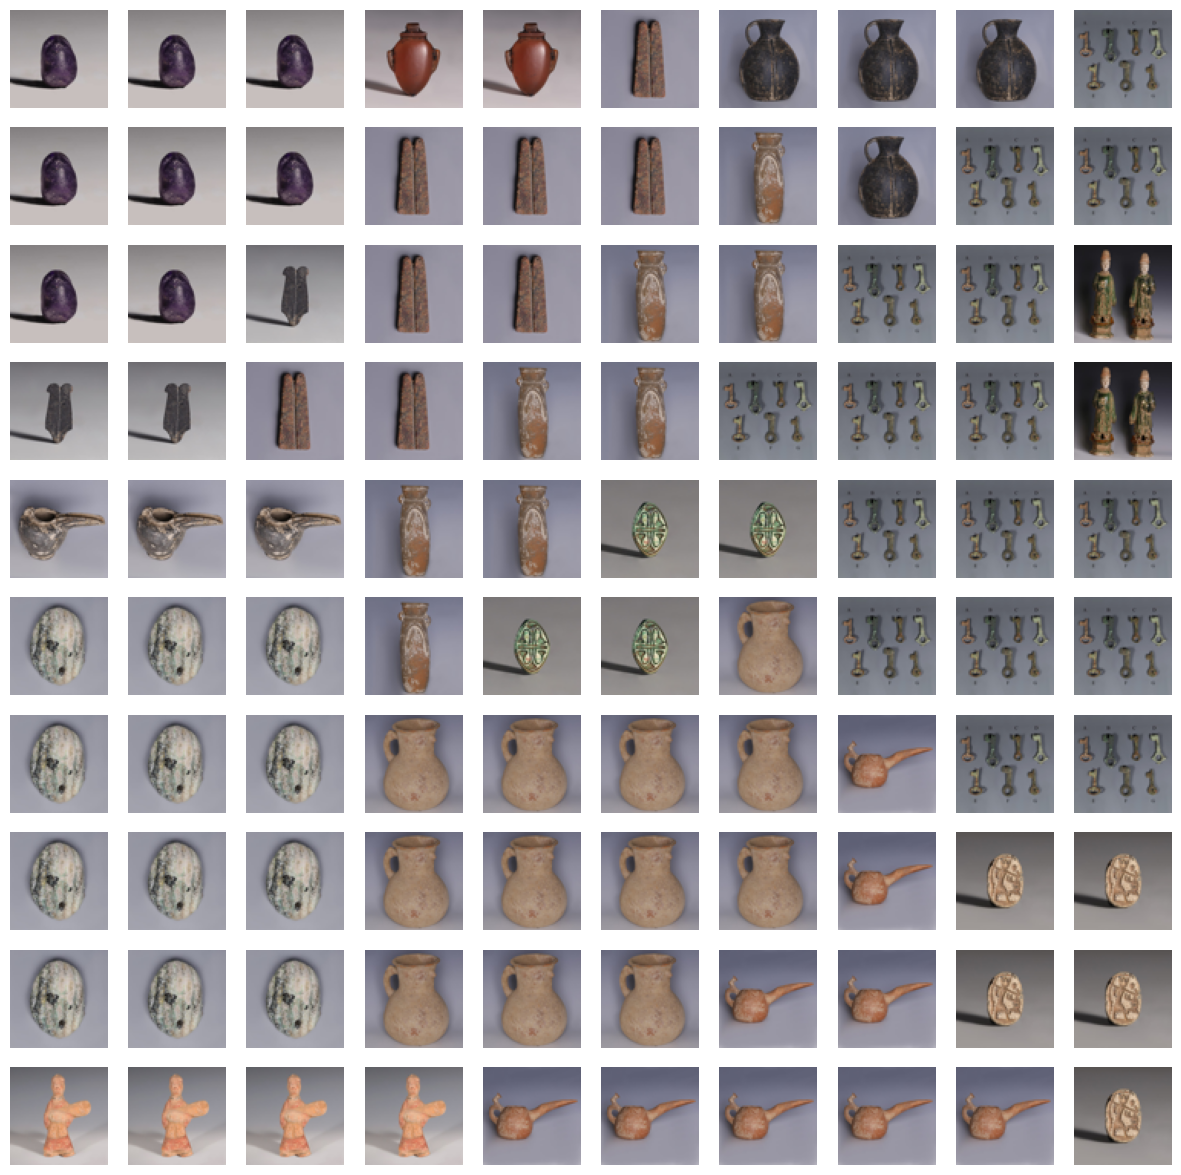

In [37]:
# Assuming the SOM is already trained and the data and image paths are provided
display_som_with_closest_images(loaded_som, data, image_paths)

3. Activation Color

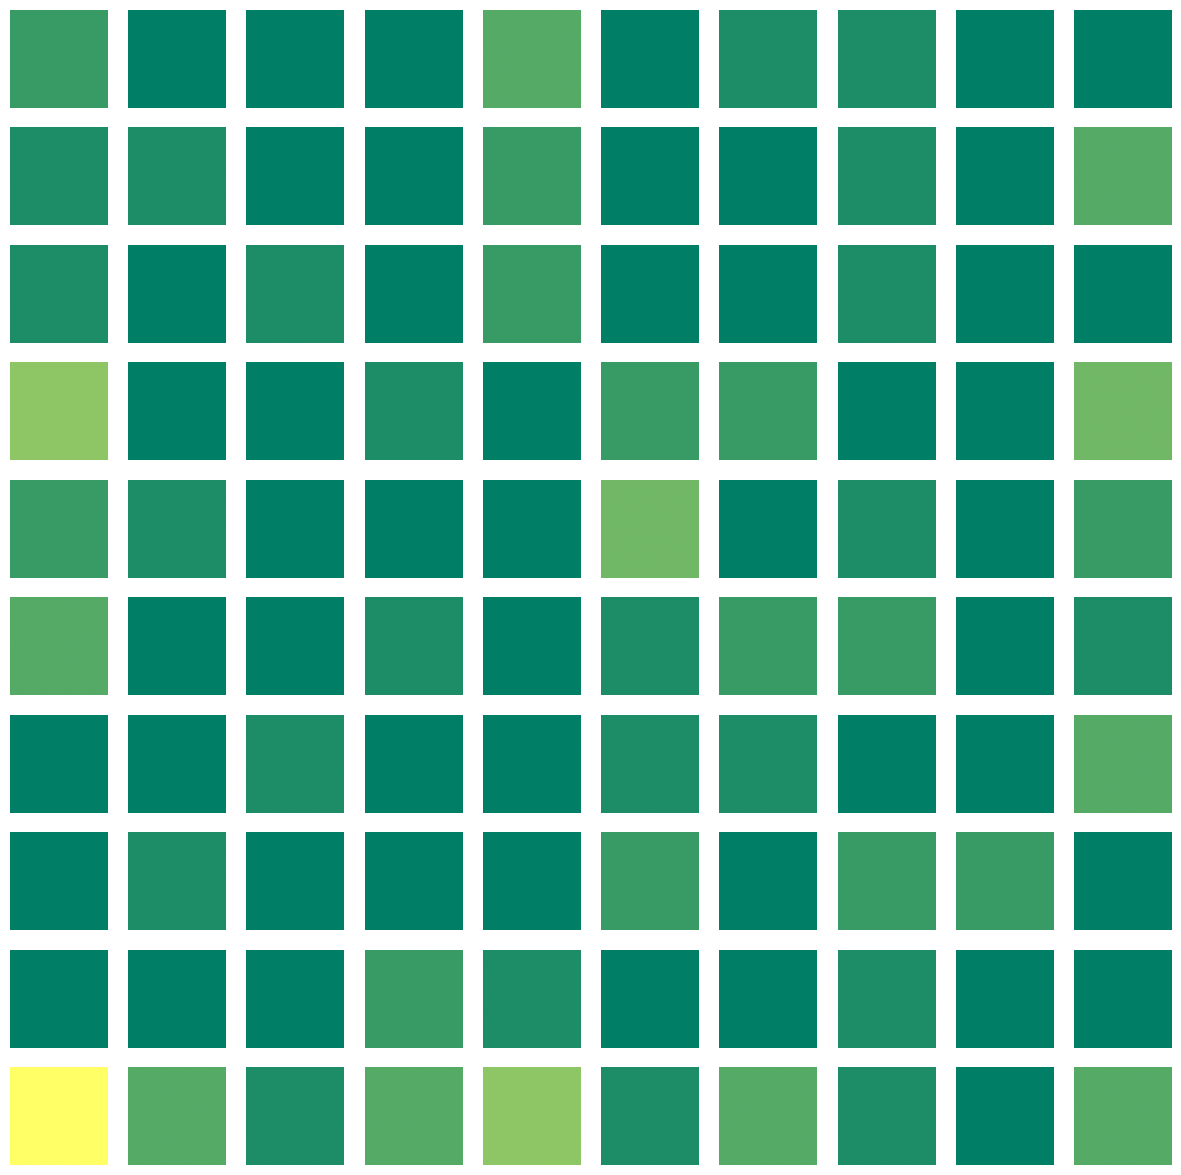

In [39]:
display_som_activation(som, data, size=(64, 64))

4. Fill Grid

AttributeError: 'NumbaSOM' object has no attribute 'get_weights'

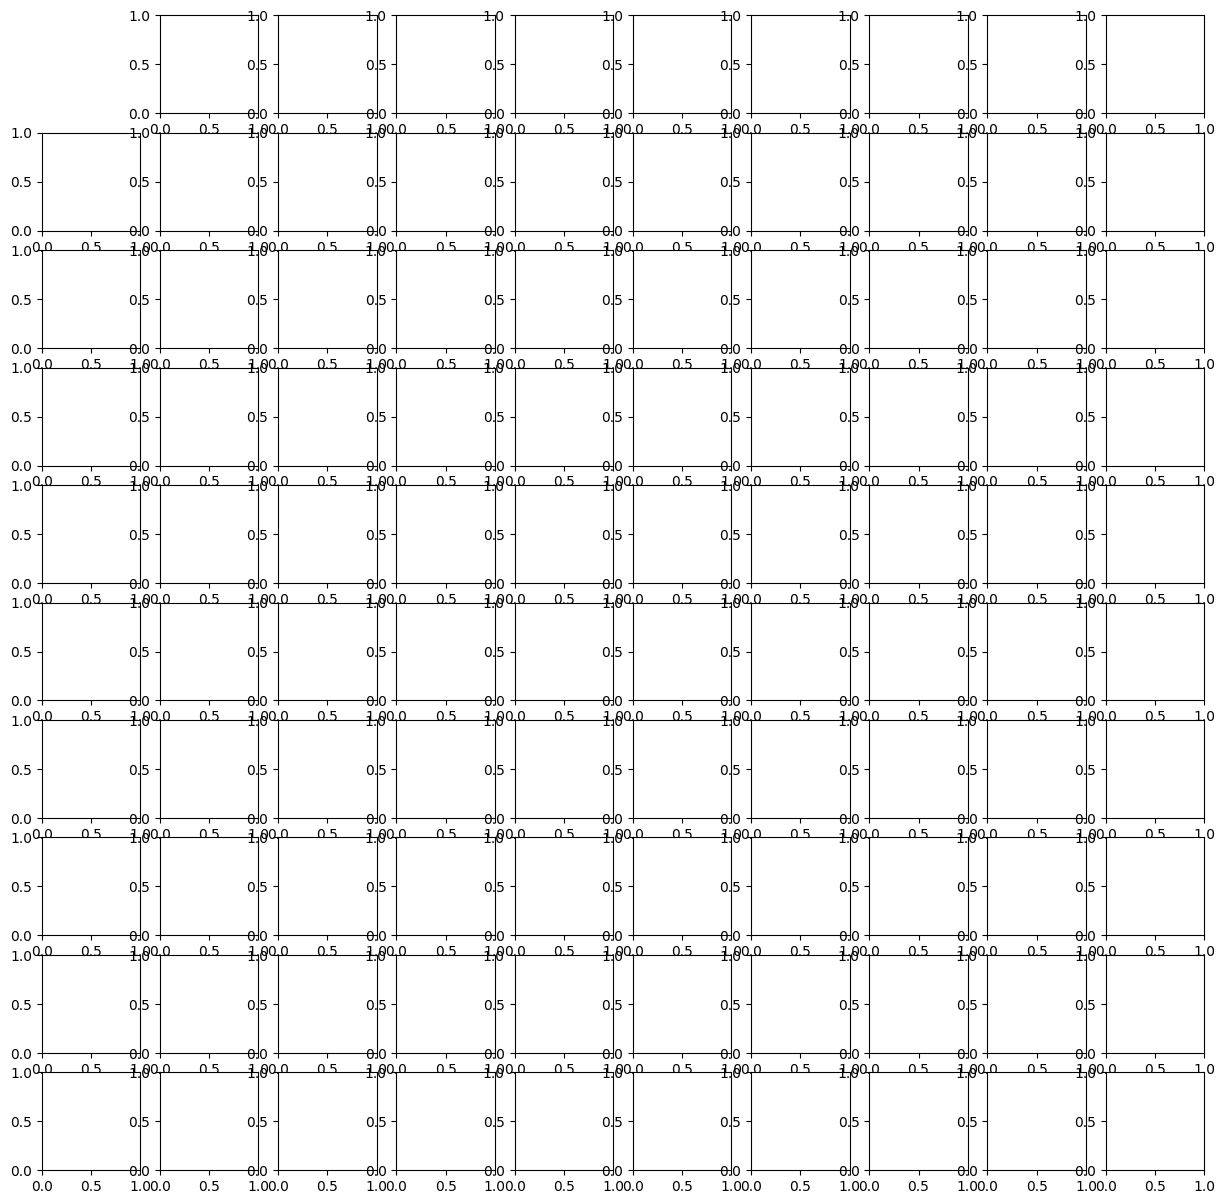

In [46]:
fill_display_som(som, data, image_paths, size=(64, 64))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [255.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [255.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [255.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [255.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [255.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [255.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [255.0..255.0].
Clipping input data to the valid range for imsho

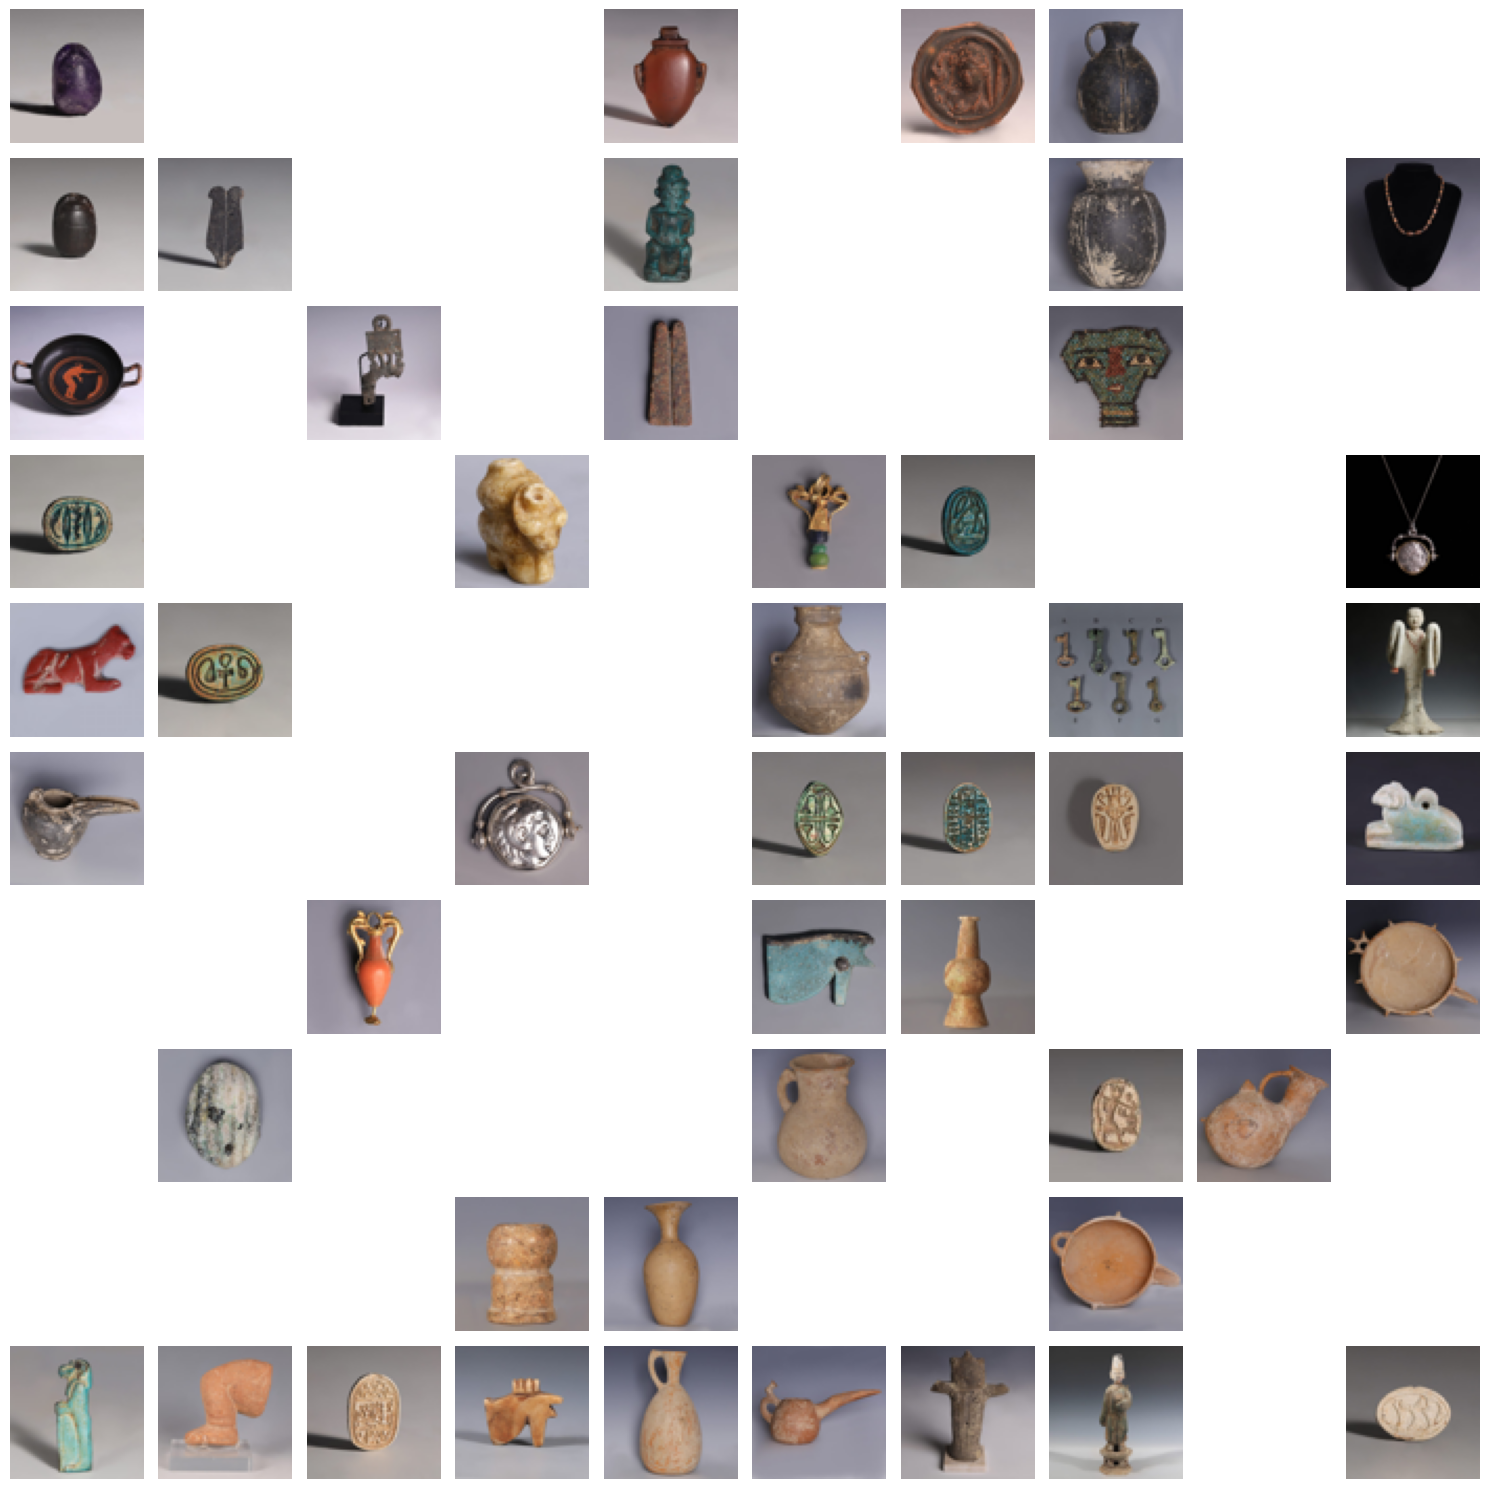

In [48]:
fill_display_som(som, data, image_paths, size=(64, 64))